# Tạo dữ liệu user giả lập

In [1]:
import pandas as pd
import numpy as np

# ================================
# 1. Load dataset sản phẩm
# ================================
products = pd.read_csv("lazada_products_clean.csv")
num_products = len(products)
print(f"Tổng sản phẩm: {num_products}")

# ================================
# 2. Nhóm keyword → category lớn
# Mỗi category gồm các keyword liên quan nhau
# User sẽ có xu hướng mua trong 1-3 category yêu thích
# ================================
CATEGORY_MAP = {
    "cong_nghe": [
        "điện thoại", "laptop", "laptop gaming", "iphone", "samsung",
        "oppo", "xiaomi", "màn hình gaming", "màn hình máy tính",
        "màn hình 144hz", "màn hình 24 inch", "màn hình cong",
        "camera an ninh", "camera wifi", "webcam máy tính",
        "micro thu âm", "loa mini", "loa soundbar", "loa vi tính",
        "máy in laser"
    ],
    "phu_kien_dien_tu": [
        "tai nghe bluetooth", "tai nghe gaming", "tai nghe không dây",
        "tai nghe chụp tai", "tai nghe airpods", "tai nghe thể thao",
        "bàn phím bluetooth", "bàn phím gaming", "bàn phím không dây",
        "bàn phím mini", "chuột gaming", "chuột bluetooth",
        "chuột không dây", "chuột logitech", "chuột máy tính",
        "miếng lót chuột gaming", "giá đỡ laptop", "giá đỡ điện thoại",
        "đế tản nhiệt laptop", "túi đựng laptop",
        "usb 128gb", "usb 64gb", "thẻ nhớ micro sd",
        "ổ cứng ssd", "ổ cứng di động",
        "cáp sạc type c", "cáp lightning", "củ sạc nhanh",
        "sạc dự phòng", "đế sạc không dây", "pin dự phòng laptop",
        "bộ chuyển đổi hdmi", "ổ cắm thông minh",
        "ốp lưng iphone", "ốp lưng samsung",
        "kính cường lực iphone", "kính cường lực samsung",
        "loa karaoke bluetooth"
    ],
    "nha_bep": [
        "nồi chiên không dầu", "bếp điện từ", "máy xay sinh tố",
        "máy ép trái cây", "ấm siêu tốc", "hộp cơm giữ nhiệt",
        "bình giữ nhiệt", "cốc giữ nhiệt", "ly giữ nhiệt",
        "bình nước thể thao", "bình nước gym"
    ],
    "nha_o": [
        "robot hút bụi", "máy hút bụi mini", "máy lọc không khí",
        "máy tạo ẩm", "máy phun sương", "quạt mini", "quạt cầm tay",
        "quạt tích điện", "đèn led trang trí", "đèn ngủ để bàn",
        "đèn bàn học", "đèn cảm biến chuyển động", "đèn ring light",
        "khung ảnh treo tường", "kệ sách gỗ", "thảm trải sàn phòng khách",
        "rèm cửa sổ", "ra giường cotton", "chăn lông cừu",
        "móc dán tường", "móc treo quần áo", "tủ nhựa mini",
        "hộp đựng tài liệu", "chuông cửa thông minh"
    ],
    "trang_diem": [
        "son môi lì", "son môi lâu trôi", "son môi chính hãng",
        "son môi mini", "son kem lì", "son tint", "son bóng",
        "son dưỡng môi", "son dưỡng có màu",
        "kem nền trang điểm", "kem nền kiềm dầu",
        "kem nền che khuyết điểm", "kem nền trang điểm tự nhiên",
        "phấn nước cushion", "phấn nền cushion",
        "cushion trang điểm", "cushion che khuyết điểm",
        "phấn phủ trang điểm", "phấn phủ kiềm dầu",
        "má hồng dạng bột", "má hồng dạng kem", "phấn má hồng",
        "bảng phấn mắt", "phấn mắt glitter",
        "mascara chống nước", "mascara làm dài mi", "mascara làm dày mi",
        "kẻ mắt dạ", "bút kẻ mắt gel", "bút kẻ mắt lâu trôi",
        "bút kẻ mắt nước", "chì kẻ mày", "gel kẻ mày",
        "bộ cọ trang điểm", "gương trang điểm",
        "túi đựng mỹ phẩm", "kem lót trang điểm",
        "kem lót kiềm dầu", "kem lót nâng tone"
    ],
    "duong_da": [
        "kem dưỡng da mặt", "kem dưỡng trắng da", "kem dưỡng ẩm",
        "kem dưỡng da ban đêm", "serum dưỡng da", "serum dưỡng ẩm",
        "serum trị mụn", "serum vitamin C", "serum vitamin c",
        "toner da mặt", "sữa rửa mặt", "sữa rửa mặt dịu nhẹ",
        "mặt nạ dưỡng da", "mặt nạ giấy", "mặt nạ ngủ",
        "mặt nạ đất sét", "kem chống nắng", "kem chống nắng cho da dầu",
        "kem chống nắng cho da nhạy cảm", "kem chống nắng nâng tone",
        "kem chống nắng spf50", "nước tẩy trang",
        "tẩy trang cho da dầu", "tẩy trang cho da nhạy cảm",
        "bông tẩy trang"
    ],
    "cham_soc_toc": [
        "dầu gội đầu", "dầu xả tóc", "kem ủ tóc",
        "tinh dầu dưỡng tóc", "máy sấy tóc", "máy uốn tóc",
        "máy duỗi tóc", "tông đơ cắt tóc", "băng đô tóc",
        "kẹp tóc thời trang"
    ],
    "the_thao": [
        "thảm yoga", "dây kháng lực", "con lăn tập bụng",
        "bóng tập gym", "dụng cụ tập kéo xà", "đai lưng hỗ trợ cột sống",
        "giày thể thao nam", "giày thể thao nữ", "giày sneaker nam",
        "giày sneaker nữ", "quần short nam", "quần short nữ",
        "áo thun nam", "áo thun nữ", "quần jogger",
        "bình nước thể thao", "bình nước gym"
    ],
    "thoi_trang": [
        "áo hoodie nam", "áo hoodie nữ", "áo khoác nam", "áo khoác nữ",
        "áo khoác jean", "áo sơ mi nữ", "quần jean nam", "quần jean nữ",
        "váy đầm nữ", "váy công sở", "váy dự tiệc", "váy maxi",
        "dép sandal", "túi xách nữ", "túi tote", "túi tote nữ",
        "túi đeo chéo", "balo du lịch", "balo laptop",
        "vòng tay thông minh", "nước hoa nam", "nước hoa nữ",
        "lăn khử mùi"
    ],
    "van_phong_hoc_tap": [
        "bút bi văn phòng", "bút highlight màu", "sổ tay ghi chép",
        "hộp bút màu", "hộp đựng tài liệu", "băng keo văn phòng",
        "máy tính casio", "ghế xoay văn phòng", "bàn học sinh",
        "sách tô màu"
    ],
    "tre_em_em_be": [
        "tã bỉm trẻ em", "bình sữa cho bé", "máy hâm sữa",
        "gối chống trào ngược", "khăn sữa cho bé", "ghế ăn dặm cho bé",
        "xe đẩy em bé", "balo trẻ em", "gối ôm hình thú",
        "bộ tô màu trẻ em", "bộ đồ chơi lego", "búp bê barbie",
        "xe đồ chơi trẻ em", "đồ chơi xếp hình",
        "đồ chơi tắm cho bé", "đồ chơi cắn răng"
    ],
    "thu_cung": [
        "thức ăn cho chó", "thức ăn cho mèo", "cát vệ sinh cho mèo",
        "dầu gội cho chó", "dụng cụ chải lông thú cưng",
        "đồ chơi cho chó", "bát ăn cho thú cưng",
        "áo cho thú cưng", "vòng cổ thú cưng", "lồng chim cảnh",
        "balo đựng thú cưng"
    ],
    "suc_khoe": [
        "máy massage cổ vai gáy", "máy đo huyết áp",
        "nhiệt kế điện tử", "thực phẩm chức năng",
        "dầu nóng xoa bóp", "bàn chải điện", "xịt chống muỗi"
    ],
    "luu_tru": [
        "hộp đựng giày", "hộp đựng đồ trang sức",
        "vỏ gối ôm", "tủ nhựa mini"
    ],
}

# Map keyword → category
keyword_to_category = {}
for cat, kws in CATEGORY_MAP.items():
    for kw in kws:
        keyword_to_category[kw] = cat

products["category"] = products["keyword"].map(keyword_to_category).fillna("khac")

print("Phân phối category:")
print(products["category"].value_counts())

# Group sản phẩm theo category
category_products = products.groupby("category")["product_id"].apply(list).to_dict()
all_categories    = list(category_products.keys())
print(f"\nTổng categories: {len(all_categories)}")


Tổng sản phẩm: 41435
Phân phối category:
category
phu_kien_dien_tu     10027
trang_diem            4569
cong_nghe             3533
thoi_trang            3513
nha_o                 3429
the_thao              2982
nha_bep               2976
duong_da              2282
tre_em_em_be          1637
cham_soc_toc          1592
khac                  1591
thu_cung              1295
van_phong_hoc_tap      890
suc_khoe               564
luu_tru                555
Name: count, dtype: int64

Tổng categories: 15


In [2]:
# ================================
# 3. Tạo user profiles có pattern
# ================================
np.random.seed(42)
num_users = 5000

# Mỗi user chọn ngẫu nhiên 1-3 category yêu thích
user_fav_categories = {}
for uid in range(1, num_users + 1):
    n_fav = np.random.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
    favs  = np.random.choice(all_categories, size=n_fav, replace=False)
    user_fav_categories[uid] = list(favs)

# ================================
# 4. Tạo interactions VECTORIZED (nhanh hơn ~20x)
# ================================
all_rows = []

for uid in range(1, num_users + 1):
    fav_cats = user_fav_categories[uid]

    # Pool sản phẩm yêu thích & ngẫu nhiên
    fav_set  = set()
    for cat in fav_cats:
        fav_set.update(category_products.get(cat, []))
    fav_pool   = list(fav_set)
    other_pool = [p for p in products["product_id"] if p not in fav_set]

    n_interact    = np.random.randint(15, 40)
    n_fav_items   = min(int(n_interact * 0.80), len(fav_pool))
    n_other_items = min(n_interact - n_fav_items, len(other_pool))

    sampled_fav   = np.random.choice(fav_pool,   size=n_fav_items,   replace=False)
    sampled_other = np.random.choice(other_pool, size=n_other_items, replace=False)

    # --- FAV items (vectorized) ---
    n_f = len(sampled_fav)
    if n_f > 0:
        purchase_f = np.random.binomial(1, 0.20, n_f)
        cart_f     = np.where(purchase_f == 1, 1, np.random.binomial(1, 0.40, n_f))
        view_f     = np.where(
            purchase_f == 1, np.random.randint(6,  15, n_f),
            np.where(cart_f == 1, np.random.randint(3, 8, n_f),
                                  np.random.randint(2, 6, n_f))
        )
        rows_f = np.column_stack([
            np.full(n_f, uid), sampled_fav, view_f, cart_f, purchase_f
        ])
        all_rows.append(rows_f)

    # --- OTHER items (vectorized) ---
    n_o = len(sampled_other)
    if n_o > 0:
        purchase_o = np.random.binomial(1, 0.03, n_o)
        cart_o     = np.where(purchase_o == 1, 1, np.random.binomial(1, 0.10, n_o))
        view_o     = np.where(
            purchase_o == 1, np.random.randint(4, 10, n_o),
            np.where(cart_o == 1, np.random.randint(2, 5, n_o),
                                  np.random.randint(1, 3, n_o))
        )
        rows_o = np.column_stack([
            np.full(n_o, uid), sampled_other, view_o, cart_o, purchase_o
        ])
        all_rows.append(rows_o)

# ================================
# 5. Tạo DataFrame & tính implicit score
# ================================
data = np.vstack(all_rows)
interactions = pd.DataFrame(
    data,
    columns=["user_id", "product_id", "view", "cart", "purchase"]
).astype(int)

interactions["implicit_score"] = (
    interactions["view"]     * 1 +
    interactions["cart"]     * 3 +
    interactions["purchase"] * 5
)

print(f"Tổng interactions : {len(interactions)}")
print(f"Unique users      : {interactions['user_id'].nunique()}")
print(f"Unique products   : {interactions['product_id'].nunique()}")
print(f"\nPhân phối implicit_score:")
print(interactions["implicit_score"].describe())
print(f"\nTỉ lệ purchase    : {interactions['purchase'].mean():.3f}")
print(f"Tỉ lệ cart        : {interactions['cart'].mean():.3f}")

interactions.to_csv("user_interactions.csv", index=False)
print("\nĐã lưu user_interactions.csv")


Tổng interactions : 135344
Unique users      : 5000
Unique products   : 38611

Phân phối implicit_score:
count    135344.000000
mean          6.667144
std           5.658910
min           1.000000
25%           2.000000
50%           5.000000
75%           9.000000
max          22.000000
Name: implicit_score, dtype: float64

Tỉ lệ purchase    : 0.164
Tỉ lệ cart        : 0.437

Đã lưu user_interactions.csv


In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import implicit

interactions = pd.read_csv("user_interactions.csv")
products_df  = pd.read_csv("lazada_products_clean.csv")
print("Interactions shape:", interactions.shape)

seg_map = {"low": 1.0, "medium": 1.1, "high": 1.2, "premium": 1.3}
rat_map = {"low": 1.0, "medium": 1.05, "good": 1.1, "excellent": 1.15}

products_df["price_boost"]  = products_df["price_segment"].map(seg_map).fillna(1.0)
products_df["rating_boost"] = products_df["rating_segment"].map(rat_map).fillna(1.0)
products_df["pop_boost"]    = 1 + products_df["popularity_score"] / 10  # 1.0 → 1.5
products_df["item_boost"]   = products_df["rating_boost"] * products_df["pop_boost"]

# Merge product features vào interactions
interactions = interactions.merge(
    products_df[["product_id", "item_boost"]],
    on="product_id", how="left"
)
interactions["item_boost"] = interactions["item_boost"].fillna(1.0)

# Tính implicit_score mới
interactions["implicit_score"] = (
    np.log1p(interactions["view"]) * 1.0 +
    interactions["cart"]          * 3.0 +
    interactions["purchase"]      * 7.0
) * interactions["item_boost"]

# Normalize bằng log1p
interactions["implicit_score"] = np.log1p(interactions["implicit_score"])

print("\nImplicit score stats (sau cải thiện):")
print(interactions["implicit_score"].describe())

# ================================================
# LEAVE-ONE-OUT SPLIT
# ================================================
np.random.seed(42)

def pick_test_item(group):
    threshold = group["implicit_score"].quantile(0.70)
    top_items = group[group["implicit_score"] >= threshold]
    return top_items.sample(1).index[0]

test_idx = interactions.groupby("user_id").apply(pick_test_item).values
train_df = interactions.copy()
test_df  = interactions.loc[test_idx].reset_index(drop=True)

print(f"\nTrain rows : {len(train_df)}")
print(f"Test rows  : {len(test_df)}")

# Sanity check
s_uid = test_df["user_id"].iloc[0]
s_pid = test_df["product_id"].iloc[0]
print(f"Sanity — test item trong train: {s_pid in train_df[train_df['user_id']==s_uid]['product_id'].values}")


c:\Users\vunam\anaconda3\envs\recsys\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Interactions shape: (135344, 6)

Implicit score stats (sau cải thiện):
count    135344.000000
mean          1.608566
std           0.747280
min           0.526589
25%           0.999534
50%           1.273102
75%           2.108327
max           3.132070
Name: implicit_score, dtype: float64

Train rows : 135344
Test rows  : 5000
Sanity — test item trong train: True


C:\Users\vunam\AppData\Local\Temp\ipykernel_14388\611983428.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_idx = interactions.groupby("user_id").apply(pick_test_item).values


In [4]:
# mapping CHỈ từ train
user_ids = train_df["user_id"].unique()
product_ids = train_df["product_id"].unique()

user_to_index = {u:i for i,u in enumerate(user_ids)}
product_to_index = {p:i for i,p in enumerate(product_ids)}

train_df["user_index"] = train_df["user_id"].map(user_to_index)
train_df["product_index"] = train_df["product_id"].map(product_to_index)

# matrix
user_item_matrix = csr_matrix(
    (
        train_df["implicit_score"],
        (train_df["user_index"], train_df["product_index"])
    )
)

In [5]:
# Train ALS model với params mặc định
# (Grid search sẽ chạy ở cell sau khi đã có test_relevant)
model = implicit.als.AlternatingLeastSquares(
    factors=64,
    regularization=0.05,
    iterations=30,
    random_state=42
)
model.fit(user_item_matrix)
print("Model training completed")
print(f"user_factors : {model.user_factors.shape}")
print(f"item_factors : {model.item_factors.shape}")

index_to_product_als = {v: k for k, v in product_to_index.items()}

def recommend_als(user_id, top_n=10):
    if user_id not in user_to_index:
        return []
    uidx        = user_to_index[user_id]
    all_scores  = model.item_factors @ model.user_factors[uidx]
    top_indices = np.argsort(all_scores)[::-1][:top_n]
    return [
        (int(index_to_product_als[i]), float(all_scores[i]))
        for i in top_indices if i in index_to_product_als
    ]


c:\Users\vunam\anaconda3\envs\recsys\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()
100%|██████████| 30/30 [00:00<00:00, 41.40it/s]

Model training completed
user_factors : (5000, 64)
item_factors : (38611, 64)


In [6]:
# User-based CF (OPTIMIZED)
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

user_item_sparse = csr_matrix(
    (
        train_df["implicit_score"],
        (train_df["user_index"], train_df["product_index"])
    ),
    shape=(len(user_ids), len(product_ids))
)
print("Sparse matrix shape:", user_item_sparse.shape)

index_to_product_cf = {v: k for k, v in product_to_index.items()}


def recommend_user_cf(user_id, top_n=10, top_k_users=20):
    if user_id not in user_to_index:
        return []

    user_idx   = user_to_index[user_id]
    sim_scores = cosine_similarity(
        user_item_sparse[user_idx], user_item_sparse
    ).flatten()

    similar_indices = np.argsort(sim_scores)[::-1][1:top_k_users + 1]

    scores = {}
    for idx in similar_indices:
        sim_score    = sim_scores[idx]
        sim_user_row = user_item_sparse[idx].toarray().flatten()
        for col_idx, val in enumerate(sim_user_row):
            if val > 0:
                pid = index_to_product_cf[col_idx]
                scores[pid] = scores.get(pid, 0) + sim_score * val

    # KHÔNG loại items đã xem → để test item có thể xuất hiện trong top K
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_n]


Sparse matrix shape: (5000, 38611)


In [ ]:
# Content-based Filtering — TF-IDF Cosine Similarity + User Profile Vector

import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix, hstack

# ================================================
# 1. CLEAN TEXT
# ================================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

products["content_cb"] = (
    products["name"].fillna("").apply(clean_text) + " " +
    (products["keyword"].fillna("").apply(clean_text) + " ") * 3 +
    products["category"].fillna("").apply(clean_text)
)

# ================================================
# 2. TF-IDF VECTORIZATION
# ================================================
tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True,
    max_features=60000
)
tfidf_matrix = tfidf.fit_transform(products["content_cb"])
tfidf_norm   = normalize(tfidf_matrix, norm='l2')
print(f"TF-IDF matrix      : {tfidf_matrix.shape}")

# ================================================
# 3. NUMERIC FEATURES
# ================================================
seg_map = {"low": 0, "medium": 1, "high": 2, "premium": 3}
rat_map = {"low": 0, "medium": 1, "good": 2, "excellent": 3}
products["price_seg_num"]  = products["price_segment"].map(seg_map).fillna(0)
products["rating_seg_num"] = products["rating_segment"].map(rat_map).fillna(0)

scaler        = MinMaxScaler()
numeric_feats = scaler.fit_transform(
    products[["price_seg_num", "rating_seg_num", "popularity_score"]]
)
print(f"Numeric features   : {numeric_feats.shape}")

# ================================================
# 4. COMBINED FEATURE MATRIX (TF-IDF 85% + Numeric 15%)
# ================================================
ALPHA = 0.15   # trọng số numeric
combined_matrix = hstack([
    tfidf_norm   * (1 - ALPHA),
    csr_matrix(numeric_feats) * ALPHA
])
combined_matrix = normalize(combined_matrix, norm='l2')  # re-normalize
combined_matrix = combined_matrix.tocsr()                # CSR cho phép matrix mul nhanh
print(f"Combined matrix    : {combined_matrix.shape}")

# ================================================
# 5. MAPPINGS product_id ↔ CB index
# ================================================
product_id_to_cb_idx = {pid: idx for idx, pid in enumerate(products["product_id"])}
cb_idx_to_product_id = {v: k for k, v in product_id_to_cb_idx.items()}

# ================================================
# 6. recommend_content (item → similar items)
# ================================================
def recommend_content(product_id, top_n=10):
    if product_id not in product_id_to_cb_idx:
        return []
    idx      = product_id_to_cb_idx[product_id]
    item_vec = combined_matrix[idx]
    scores   = (combined_matrix @ item_vec.T).toarray().flatten()
    scores[idx] = -1   # loại chính nó
    top_idx  = np.argsort(scores)[::-1][:top_n]
    return [(int(cb_idx_to_product_id[i]), float(scores[i])) for i in top_idx]

# ================================================
# 7. recommend_content_for_user — USER PROFILE VECTOR
# ================================================
def recommend_content_for_user(user_id, top_n=10):
    user_data = train_df[train_df["user_id"] == user_id]
    if user_data.empty:
        return []

    pids    = user_data["product_id"].values
    weights = user_data["implicit_score"].values.astype(float)

    # Lọc products có trong CB index
    valid   = np.array([p in product_id_to_cb_idx for p in pids])
    pids    = pids[valid]
    weights = weights[valid]
    if len(pids) == 0:
        return []

    indices = np.array([product_id_to_cb_idx[p] for p in pids])
    w_norm  = weights / weights.sum()   # normalize weights

    # Vectorized weighted sum: shape (1, n_features)
    profile_vec = csr_matrix(w_norm.reshape(1, -1)).dot(combined_matrix[indices])
    profile_vec = normalize(profile_vec, norm='l2')

    # Score toàn bộ catalogue
    all_scores = (combined_matrix @ profile_vec.T).toarray().flatten()

    top_idx = np.argsort(all_scores)[::-1][:top_n]
    return [
        (int(cb_idx_to_product_id[i]), float(all_scores[i]))
        for i in top_idx
    ]

print("\nContent-based (TF-IDF + User Profile Vector) sẵn sàng.")


TF-IDF matrix      : (41435, 60000)
Numeric features   : (41435, 3)
Combined matrix    : (41435, 60003)

Content-based (TF-IDF + User Profile Vector) sẵn sàng.


In [8]:
# Test thử 1 user
product_id_to_name = dict(zip(products["product_id"], products["name"]))

user_id = 1

als_results = recommend_als(user_id)
ucf_results = recommend_user_cf(user_id)
cb_results  = recommend_content_for_user(user_id)

def print_results(title, results):
    print(f"\n=== {title} ===")
    for pid, score in results:
        name = product_id_to_name.get(pid, "Unknown")
        print(f"{pid} | {name[:40]} | {score:.4f}")

print_results("ALS", als_results)
print_results("User-CF", ucf_results)
print_results("Content-based", cb_results)


=== ALS ===
29434 | Bờm tóc/ Cài tóc Công Chúa Elsa cho bé g | 0.0344
26742 | Máy Duỗi Tóc Cao Cấp CF-199 Bản Sứ Bảo V | 0.0320
25539 | Dầu chăm sóc tóc xoăn, dầu xả tóc,Hair C | 0.0296
27436 | Kẹp Tóc Hàn Quốc Càng Cua Phối Lông Cute | 0.0285
24900 | Máy Sấy Tóc 2 Chiều Nóng ,Lạnh Công Suất | 0.0284
29742 | LEKGAVD Tua rua Băng đô lông vũ Có thể đ | 0.0269
26587 | ANLAN Negative Ion Wireless Hair Straigh | 0.0259
25515 | DẦU XẢ SUNSILK BỒ KẾT ÓNG MƯỢT RẠNG NGỜI | 0.0255
4058 | Màn hình máy tính 27inch GIGABYTE G27F 2 | 0.0243
15007 | EHOMEWEI | Portable External Monitor 16  | 0.0242

=== User-CF ===
4178 | Màn hình LCD 27'' Glowy G27C100 Cong 100 | 0.8319
19007 | TEFAL - Nồi chiên không dầu 4.2L Tefal 2 | 0.3872
14415 | (Only 15-17.08) elmich ice-1832 inductio | 0.3814
27911 | Tinh dầu bưởi cocon giảm gãy rụng mọc tó | 0.3767
32966 | Sách Bé Tô Màu 8 Chủ Đề Bộ 8 Quyển Tô Mà | 0.3646
21967 | Quạt tích điện 12 inch dùng pin MKT 18v  | 0.3628
32591 | Micro Thu Âm Điện Tử K9 Thế Hệ Mới L

# Đánh giá và so sánh 3 mô hình

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# ================================================
# GROUND TRUTH: mỗi user có đúng 1 relevant item
# ================================================
K = 10

test_relevant = (
    test_df
    .groupby("user_id")["product_id"]
    .apply(set)
    .to_dict()
)

print(f"Số users trong test  : {len(test_relevant)}")
print(f"Relevant items/user  : {np.mean([len(v) for v in test_relevant.values()]):.2f}  (= 1)")

# Sanity: test item có trong train không?
sample_uid  = list(test_relevant.keys())[0]
sample_pid  = list(test_relevant[sample_uid])[0]
train_items = set(train_df[train_df["user_id"] == sample_uid]["product_id"])
print(f"\nVí dụ user {sample_uid}:")
print(f"  Relevant item   : {sample_pid}")
print(f"  Có trong train  : {sample_pid in train_items}  ← phải True")
print(f"  Recs (ALS)      : {[p for p,_ in recommend_als(sample_uid)]}")
print(f"  Item xuất hiện  : {sample_pid in [p for p,_ in recommend_als(sample_uid)]}")


Số users trong test  : 5000
Relevant items/user  : 1.00  (= 1)

Ví dụ user 1:
  Relevant item   : 4178
  Có trong train  : True  ← phải True
  Recs (ALS)      : [29434, 26742, 25539, 27436, 24900, 29742, 26587, 25515, 4058, 15007]
  Item xuất hiện  : False


In [ ]:
# ================================================
# GRID SEARCH: tìm hyperparameters tốt nhất cho ALS
# ================================================
PARAM_GRID = [
    {"factors": 32,  "regularization": 0.01, "iterations": 20},
    {"factors": 64,  "regularization": 0.01, "iterations": 30},
    {"factors": 64,  "regularization": 0.05, "iterations": 30},
    {"factors": 128, "regularization": 0.01, "iterations": 30},
    {"factors": 128, "regularization": 0.05, "iterations": 50},
    {"factors": 256, "regularization": 0.05, "iterations": 50},
]

EVAL_USERS = list(test_relevant.keys())[:200]

def ndcg_quick(recommended, relevant, k=10):
    dcg  = sum(1/np.log2(i+2) for i, p in enumerate(recommended[:k]) if p in relevant)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg/idcg if idcg > 0 else 0.0

def quick_eval_als(m, k=10):
    scores = []
    for uid in EVAL_USERS:
        if uid not in user_to_index or uid not in test_relevant:
            continue
        uidx    = user_to_index[uid]
        all_sc  = m.item_factors @ m.user_factors[uidx]
        top_idx = np.argsort(all_sc)[::-1][:k]
        recs    = [int(index_to_product_als[i]) for i in top_idx if i in index_to_product_als]
        scores.append(ndcg_quick(recs, test_relevant[uid], k))
    return np.mean(scores)

print("🔍 Grid Search ALS hyperparameters...")
print("-" * 58)

best_score  = -1
best_params = None
best_model  = None

for params in PARAM_GRID:
    m = implicit.als.AlternatingLeastSquares(
        factors=params["factors"],
        regularization=params["regularization"],
        iterations=params["iterations"],
        random_state=42
    )
    m.fit(user_item_matrix, show_progress=False)
    score = quick_eval_als(m)
    flag  = "  ← best" if score > best_score else ""
    print(f"  factors={params['factors']:3d}  reg={params['regularization']}  iter={params['iterations']:2d}  NDCG@10={score:.4f}{flag}")
    if score > best_score:
        best_score  = score
        best_params = params
        best_model  = m

print("-" * 58)
print(f"\n✅ Best params : {best_params}")
print(f"✅ Best NDCG@10: {best_score:.4f}")

# Cập nhật model và recommend_als với best model
model = best_model

def recommend_als(user_id, top_n=10):
    if user_id not in user_to_index:
        return []
    uidx        = user_to_index[user_id]
    all_scores  = model.item_factors @ model.user_factors[uidx]
    top_indices = np.argsort(all_scores)[::-1][:top_n]
    return [
        (int(index_to_product_als[i]), float(all_scores[i]))
        for i in top_indices if i in index_to_product_als
    ]

print("\n✅ recommend_als đã được cập nhật với best model")


🔍 Grid Search ALS hyperparameters...
----------------------------------------------------------


  factors= 32  reg=0.01  iter=20  NDCG@10=0.0448  ← best
  factors= 64  reg=0.01  iter=30  NDCG@10=0.1273  ← best
  factors= 64  reg=0.05  iter=30  NDCG@10=0.1273
  factors=128  reg=0.01  iter=30  NDCG@10=0.2144  ← best
  factors=128  reg=0.05  iter=50  NDCG@10=0.2176  ← best
  factors=256  reg=0.05  iter=50  NDCG@10=0.3113  ← best
----------------------------------------------------------

✅ Best params : {'factors': 256, 'regularization': 0.05, 'iterations': 50}
✅ Best NDCG@10: 0.3113

✅ recommend_als đã được cập nhật với best model


In [ ]:
# ================================================
# HÀM TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ\
# ================================================

def precision_at_k(recommended, relevant, k):
    """Tỉ lệ item liên quan trong top-K kết quả gợi ý."""
    hits = len(set(recommended[:k]) & relevant)
    return hits / k


def recall_at_k(recommended, relevant, k):
    """Tỉ lệ item liên quan được tìm thấy trong top-K."""
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / len(relevant)


def ap_at_k(recommended, relevant, k):
    """Average Precision@K — tính AP cho một user.
    AP = (1/R) * sum_{i=1}^{K} [P@i * rel(i)]
    với R = số item relevant, rel(i) = 1 nếu item thứ i là relevant.
    """
    if not relevant:
        return 0.0
    hits      = 0
    score_sum = 0.0
    for i, pid in enumerate(recommended[:k]):
        if pid in relevant:
            hits      += 1
            score_sum += hits / (i + 1)   # Precision tại vị trí i+1
    return score_sum / len(relevant)


def ndcg_at_k(recommended, relevant, k):
    """Normalized Discounted Cumulative Gain@K.
    Ưu tiên item đúng xuất hiện ở vị trí càng cao (rank nhỏ) càng tốt.
    """
    dcg = sum(
        1 / np.log2(i + 2)
        for i, pid in enumerate(recommended[:k])
        if pid in relevant
    )
    ideal_hits = min(len(relevant), k)
    idcg       = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_model(recommend_fn, test_relevant, k=10, max_users=None, model_name="Model"):
    precisions, recalls, aps, ndcgs = [], [], [], []

    users_to_eval = list(test_relevant.keys())
    if max_users:
        users_to_eval = users_to_eval[:max_users]

    for user_id in tqdm(users_to_eval, desc=f"Evaluating {model_name}"):
        relevant    = test_relevant[user_id]
        recs        = recommend_fn(user_id)
        recommended = [pid for pid, _ in recs]

        if not recommended:
            continue

        precisions.append(precision_at_k(recommended, relevant, k))
        recalls.append(recall_at_k(recommended, relevant, k))
        aps.append(ap_at_k(recommended, relevant, k))
        ndcgs.append(ndcg_at_k(recommended, relevant, k))

    return {
        "Model"           : model_name,
        f"Precision@{k}"  : np.mean(precisions),
        f"Recall@{k}"     : np.mean(recalls),
        f"MAP@{k}"        : np.mean(aps),
        f"NDCG@{k}"       : np.mean(ndcgs),
        "Evaluated users" : len(precisions),
    }


print("Hàm đánh giá đã sẵn sàng (Precision | Recall | MAP | NDCG).")


Hàm đánh giá đã sẵn sàng (Precision | Recall | MAP | NDCG).


In [ ]:
# ================================================
# CHẠY ĐÁNH GIÁ 3 MÔ HÌNH
# ================================================
MAX_USERS = 500

results_als = evaluate_model(
    recommend_fn=lambda uid: recommend_als(uid, top_n=K),
    test_relevant=test_relevant,
    k=K, max_users=MAX_USERS, model_name="ALS"
)

results_ucf = evaluate_model(
    recommend_fn=lambda uid: recommend_user_cf(uid, top_n=K),
    test_relevant=test_relevant,
    k=K, max_users=MAX_USERS, model_name="User-CF"
)

results_cb = evaluate_model(
    recommend_fn=lambda uid: recommend_content_for_user(uid, top_n=K),
    test_relevant=test_relevant,
    k=K, max_users=MAX_USERS, model_name="Content-based"
)

# ================================================
# HIỂN THỊ KẾT QUẢ
# ================================================
results_df   = pd.DataFrame([results_als, results_ucf, results_cb]).set_index("Model")
display_cols = [f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]

print("\n" + "="*62)
print(f"  KẾT QUẢ ĐÁNH GIÁ — Leave-One-Out  (K={K}, {MAX_USERS} users)")
print("="*62)
print(results_df[display_cols].applymap(lambda x: f"{x:.4f}"))
print("="*62)
print(f"  Evaluated users: {results_als['Evaluated users']}")
print("="*62)

print("\n🏆 Mô hình tốt nhất theo từng chỉ số:")
for col in display_cols:
    best = results_df[col].idxmax()
    print(f"  {col:15s}: {best} ({results_df[col].max():.4f})")


Evaluating Content-based: 100%|██████████| 500/500 [00:05<00:00, 86.29it/s]


  KẾT QUẢ ĐÁNH GIÁ — Leave-One-Out  (K=10, 500 users)
              Precision@10 Recall@10  MAP@10 NDCG@10
Model                                               
ALS                 0.0588    0.5880  0.2113  0.2992
User-CF             0.0418    0.4180  0.2023  0.2541
Content-based       0.0240    0.2400  0.1225  0.1505
  Evaluated users: 500

🏆 Mô hình tốt nhất theo từng chỉ số:
  Precision@10   : ALS (0.0588)
  Recall@10      : ALS (0.5880)
  MAP@10         : ALS (0.2113)
  NDCG@10        : ALS (0.2992)



C:\Users\vunam\AppData\Local\Temp\ipykernel_14388\3538115173.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(results_df[display_cols].applymap(lambda x: f"{x:.4f}"))


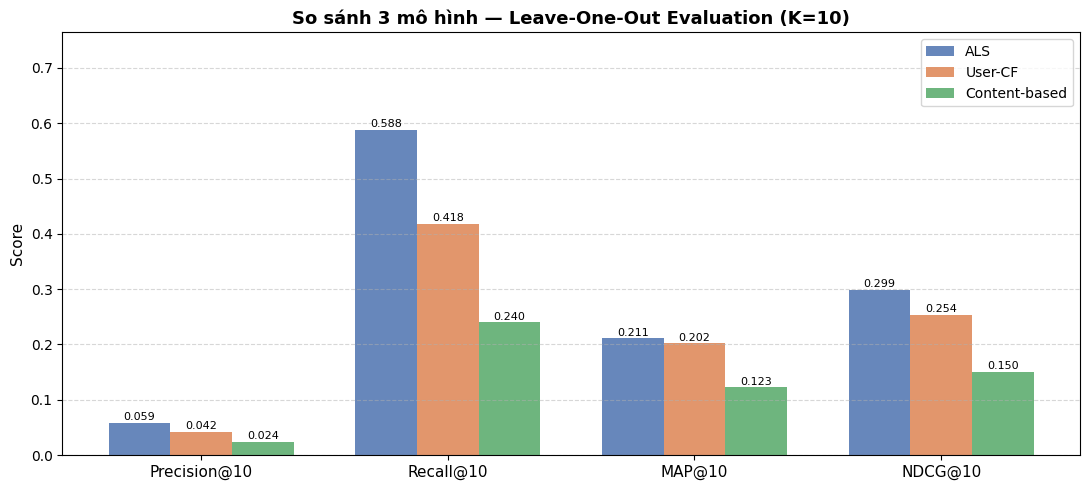

Đã lưu biểu đồ: model_comparison.png


In [13]:
import matplotlib.pyplot as plt

metrics = [f"Precision@{K}", f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]
models  = results_df.index.tolist()
colors  = ["#4C72B0", "#DD8452", "#55A868"]

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    f"So sánh 3 mô hình — Leave-One-Out Evaluation (K={K})",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.set_ylim(0, max(results_df[metrics].values.max() * 1.3, 0.1))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: model_comparison.png")
